In [ ]:

# Bicanski 2026 - UCM: universal cognitive maps
# https://doi.org/10.1016/j.cub.2026.08.064
# correspondence: bicanski@cbs.mpg.de

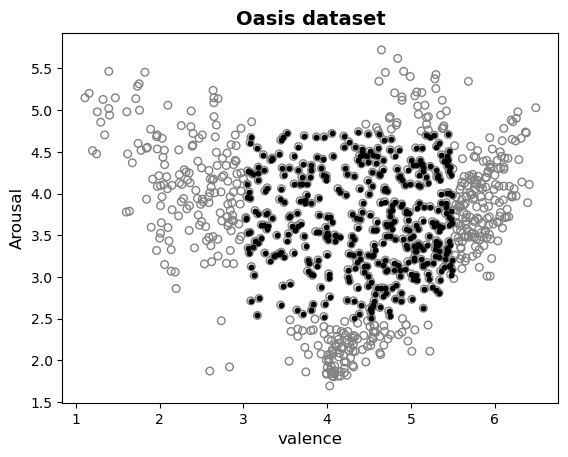

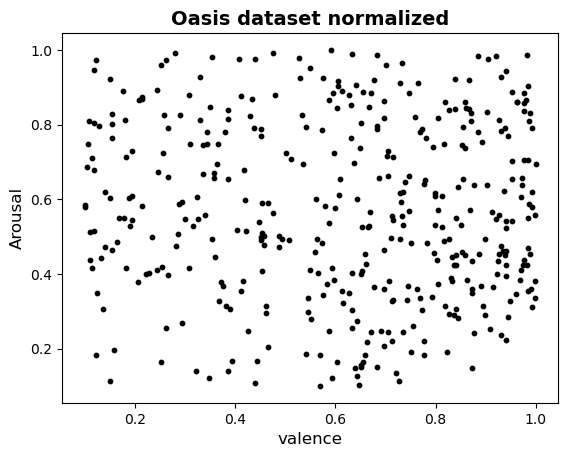

In [1]:
# load OASIS dataset and rescale

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from helper_fcts import check_dataset_range
from helper_fcts import load_GCs

from prep_datasets import prep_oasis
from prep_datasets import make_oasis_synthetic
from prep_datasets import get_distances

# grid cells
GCs, res, N_GCs, N_mod, N_per_mod = load_GCs()

data0 = pd.read_csv("datasets/oasis/ExpData/OASIS.csv", sep=None, engine="python")
IDs  = data0.iloc[:, 0].to_numpy()

data, val, aro = prep_oasis(data0,4,res)
dim1range, dim2range, prop, S1ind, S1coords, N_pts = check_dataset_range(data=data, dim1=val, dim2=aro, mapsize=res)

aro = aro/np.max(aro)
val = val/np.max(val)

plt.scatter(val, aro, s=10, facecolors='black', edgecolors='black')
plt.xlabel("valence", fontsize=12, color='black')
plt.ylabel("Arousal", fontsize=12, color='black')
plt.title("Oasis dataset normalized", fontsize=14, fontweight='bold')
plt.show()


In [2]:
# helper functions

def make_attribute(sp, N):
    active = np.random.rand(N) >= sp     # which stimuli fire for this attribute
    mag    = np.random.rand(N)           # which neuron in the magnitude bank (uniform)
    return active * mag

def assign_bank_neuron(att,N_mag,n_banks,Nn,I_stim):
    n_bins = N_mag
    bins   = np.floor(att * n_bins).astype(int)
    bins   = np.clip(bins, 0, n_bins - 1)
    active = att != 0    # 0 means whole bank silent
    banks  = np.arange(n_banks)
    ind    = banks[active] * N_mag + bins[active]
    I      = np.zeros((Nn, 1))
    I[ind, 0] = I_stim
    return I

# note, the rate code assumes one magnitude neuron per attribute
def assign_rates(att, N_magA):
    bins = np.floor(att * N_magA).astype(int)
    bins = np.clip(bins, 0, N_magA - 1)         #
    rate_ind = bins + 1                        # 1..10, leaving I_stim[0]=0 for silent
    rate_ind[att == 0] = 0                     # silent banks pick I_stim[0]=0
    return rate_ind

In [3]:
# make stimulus attribute vectors, adding "useless" random dimensions

N_att = 10   # 2 of these are val aro

attributes = np.zeros([N_pts, N_att])

attributes[:,0] = val
attributes[:,1] = aro
attributes[:,2] = make_attribute(0.75,N_pts)
attributes[:,3] = make_attribute(0.95,N_pts)
attributes[:,4] = make_attribute(0.85,N_pts)
attributes[:,5] = make_attribute(0.90,N_pts)
attributes[:,6] = make_attribute(0.60,N_pts)
attributes[:,7] = make_attribute(0.80,N_pts)
attributes[:,8] = make_attribute(0.50,N_pts)
attributes[:,9] = make_attribute(0.40,N_pts)

np.set_printoptions(precision=2, suppress=True)
print('test', attributes[0:9,:])

test [[0.7  0.24 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.55 0.3  0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.73 0.24 0.38 0.53 0.   0.   0.16 0.   0.28 0.21]
 [0.94 0.52 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.65 0.16 0.   0.   0.   0.   0.   0.   0.   0.73]
 [0.63 0.35 0.01 0.   0.   0.   0.   0.   0.12 0.97]
 [0.99 0.62 0.   0.   0.   0.   0.56 0.   0.   0.53]
 [0.15 0.46 0.   0.   0.   0.   0.   0.   0.67 0.  ]
 [0.19 0.55 0.   0.   0.   0.   0.   0.   0.   0.61]]


In [4]:
# Make extra attributes, run a neural "integrator" and for each attribute
# First, labeled line flavor, bank of magnitude neurons

### init

N_mag  = 10   # number of cells per magnitude bank, 10 per attribute
N_magA = 10 * N_mag
N_int  = 10   # total number of integrator neurons, one per attribute
Nn     = N_magA + N_int

t_S    = 50
t_sim  = N_pts*t_S # short, but h we could make it more
dt     = 1  
dtvec  = np.ones((Nn,1), float)*dt

thresh = np.zeros((Nn,1), float)-40
refrac = 3/dt   

Tmem              = np.zeros((Nn,1), float)
Tmem[0:N_magA,0]  = 4.2                                        
Tmem[N_magA:Nn,0] = 4.2  

R              = np.zeros((Nn,1), float)
R[0:N_magA,0]  = 15               
R[N_magA:Nn,0] = 15 

delay  = 2   # synaptic delay, not really needed, left over from my CPG models

### connectivity
Wampa   = np.zeros((Nn, Nn), float)
Wnmda   = np.zeros((Nn, Nn), float)
n_banks = N_magA // N_mag      # 10
for i in range(n_banks):
    Wampa[N_magA+i, i*N_mag:(i+1)*N_mag] = 1   # [target_row, source_cols]
    Wnmda[N_magA+i, i*N_mag:(i+1)*N_mag] = 1

### Loop N_it times for averages

N_it = 20

dataVall = np.zeros((Nn,t_sim,N_it))

for j in range(N_it):

    gAMPA = np.zeros((Nn,1), float);   dAMPA = 0.067;   Erev_ampa =   0;   Tampa    = 10
    gNMDA = np.zeros((Nn,1), float);   dNMDA = 0.1;     Erev_nmda =   0;   Tnmda    = 100

    AMPAincr = np.zeros((Nn,1), float);        
    NMDAincr = np.zeros((Nn,1), float);
    
    count = -1
    t     = 1
    
    V_rest  = np.zeros((Nn,1), float)-70;                                       
    E_leak  = V_rest.copy()
    V_reset = np.zeros((Nn,1), float)-80;   

    g_leak = 1 # left over from older implementation, interpret as gain, not really a leak conductance

    Iext = np.zeros((Nn,1), float)
    Vold = np.zeros((Nn,1), float) + V_rest  
    Vnew = np.zeros((Nn,1), float)
    Vbef = np.copy(Vold)

    FRwindow = 100                                     # FR estimated from last 100 ms
    buffer   = np.ones((Nn,FRwindow+1), float)*-1      # combined buffer for delayed synaptic transm. and FR estimate
    buffind  = 0                                       

    clampflag    = np.zeros((Nn,1), float)
    clampbef     = np.zeros((Nn,1), float)
    intercept_dt = np.zeros((Nn,1), float)

    frate  = np.zeros((Nn,1), float)   # dummy
    dataV  = np.zeros((Nn,t_sim), float)-70
    dataFR = np.zeros((Nn,t_sim), float)   

    ### make stimulus attribute vectors, adding "useless" random dimensions

    N_att = 10   # 2 of these are val aro
    attributes      = np.zeros([N_pts, N_att])
    
    sparseness = [0.0, 0.0, 0.75, 0.95, 0.85, 0.90, 0.60, 0.80, 0.50, 0.40]
    
    for i in range(2, N_att):
        attributes[:, i] = make_attribute(sparseness[i], N_pts)
    
    perm = np.random.permutation(N_pts)
    attributes[:,0] = val[perm]
    attributes[:,1] = aro[perm]

    np.set_printoptions(precision=2, suppress=True)
    print('test', attributes[0:1,:])

    ### simulation loop

    S_count = 0   # stimulus ID

    I_stim = 2.4

    while t < t_sim:
        
        count = count + 1
        
        if (t-1) % t_S == 0 and S_count < N_pts:
            Iext = assign_bank_neuron(attributes[S_count,:],N_mag,n_banks,Nn,I_stim)
            S_count += 1
            
        Vnew = Vold.copy()
        assert Vold is not Vnew and Vold is not Vbef and Vnew is not Vbef, \
        "state arrays aliased — copy-on-assign bug"
        # because I am still used to Matlab
            
        ind1 = Vold>=thresh
        ind2 = Vbef<thresh
        ind3 = np.logical_and(ind1,ind2)   # determine which neurons crossed threshold
        
        if any(ind3):                                                          # does not affect clamped neurons       
            Vslopes              = np.copy(dtvec)                              # dtvec = prealloc ones*dt, length Nn
            Vslopes[ind3]        = (Vnew[ind3]-Vbef[ind3])/dt                  # cells that crossed thresh determine slope of V within timestep
            intercept_dt[ind3]   = (thresh[ind3]-Vbef[ind3])/Vslopes[ind3]     # dt - this = amount of dt-like integration within this timestep
            
            indW = np.where(ind3==True)
            
            buffer[indW[0],[buffind]] = t-dt+intercept_dt[ind3]                 # enter spike time in buffer
            
            buffer[:,buffind]  = buffer[:,buffind]*ind3[:,0]
            Vnew[ind3]         = V_reset[ind3]
            clampflag[ind3]    = refrac
            
        dtintneu = np.copy(dtvec)   # this needs to be aadapted when neuron exits refrec                                                                    
        ind4     = Vold<thresh      # see implementation note *5
        ind5     = clampflag<0                                                    
        ind7     = clampbef>=0

        if any(ind5):
            ind6   = np.logical_and(ind4,ind5)
        else:
            ind6   = np.zeros((Nn,1), bool)       

        dtint = np.copy(dtvec)                                   # integration dt same for all
        inddt = np.logical_and(ind6,ind7)                        # clamping released during this timestep
        if any(inddt):
            dtintneu[inddt] = dtint[inddt]-intercept_dt[inddt]   # see above notes *1 and *2             
            

        if t > delay + 1:
            b_ind = int(buffind - delay)
            if b_ind < 0:
                b_ind += FRwindow + 1         

            indSP = buffer[:, b_ind] > 0

            scaledAMPA = np.inner(Wampa, indSP).reshape(-1, 1)
            scaledNMDA = np.inner(Wnmda, indSP).reshape(-1, 1)

            gAMPA += dAMPA * scaledAMPA        # all cells, refractory or not
            gNMDA += dNMDA * scaledNMDA
        
        if any(ind6): 
            Vnew[ind6] = Vold[ind6] + dtintneu[ind6]/Tmem[ind6] * ( - g_leak*( Vold[ind6] - E_leak[ind6] )
            + R[ind6] * Iext[ind6] ) + dtint[ind6] / Tmem[ind6] * ( - gAMPA[ind6] * (Vold[ind6] - Erev_ampa) 
            - gNMDA[ind6] * (Vold[ind6] - Erev_nmda) )  

        gAMPA = gAMPA + dt/Tampa*(-gAMPA)
        gNMDA = gNMDA + dt/Tnmda*(-gNMDA)

        if t<101:
            FR = np.sum(buffer>0,1)*1000/FRwindow;   # slow, but can be substituted once buffer filled
        else:
            newest = (buffer[:,buffind] > 0).astype(float)
            FR = FRbef + (newest - oldest) * 1000 / FRwindow

        dataV[:,[count]]          = Vold;
        dataFR[:,[count]]         = np.transpose([FR]);
        
        Vbef      = Vold.copy() 
        Vold      = Vnew  # alias, broken next iteration by Vnew = Vold.copy()
        t         = t + dt
        FRbef     = FR.copy()
        clampbef  = clampflag.copy()
        clampflag = clampflag-1          #-1 because clampflag=refrac and refrac already devided by dt
        
        buffind = (buffind + 1) % 101
        oldest  = (buffer[:,buffind] > 0).astype(float)
        buffer[:,buffind] = 0            # buffind updated, zero out what was previously written there, 100 ms ago
        
        AMPAincr[:] = 0
        NMDAincr[:] = 0
        
    print('Done')
    dataVall[:,:,j]      = dataV
    
filename1 = f"simdata_magcode.npy"
np.save(filename1, dataVall)
    

test [[0.15 0.11 0.21 0.   0.26 0.   0.   0.27 0.   0.87]]
Done
test [[0.91 0.25 0.   0.   0.66 0.   0.43 0.3  0.   0.39]]
Done
test [[0.87 0.81 0.   0.   0.   0.   0.   0.   0.54 0.61]]
Done
test [[0.76 0.82 0.   0.   0.25 0.   1.   0.31 0.   0.  ]]
Done
test [[0.61 0.9  0.   0.   0.   0.   0.   0.29 0.   0.17]]
Done
test [[0.94 0.46 0.   0.   0.   0.   0.96 0.   0.79 0.86]]
Done
test [[0.63 0.4  0.   0.   0.   0.   0.5  0.64 0.48 0.3 ]]
Done
test [[0.98 0.44 0.61 0.   0.   0.   0.   0.   0.51 0.02]]
Done
test [[0.35 0.98 0.   0.   0.   0.   0.   0.   0.   0.88]]
Done
test [[0.89 0.75 0.   0.   0.   0.   0.39 0.   0.74 0.06]]
Done
test [[0.1  0.58 0.96 0.22 0.   0.   0.   0.   0.   0.15]]
Done
test [[0.83 0.49 0.71 0.   0.   0.   0.   0.   0.   0.78]]
Done
test [[0.96 0.86 0.   0.   0.   0.   0.   0.   0.98 0.  ]]
Done
test [[0.7  0.73 0.   0.   0.   0.   0.   0.   0.   0.23]]
Done
test [[0.59 0.87 0.   0.   0.   0.   0.71 0.9  0.   0.  ]]
Done
test [[0.35 0.85 0.   0.   0.   0.   0. 

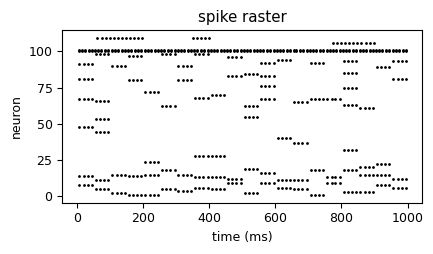

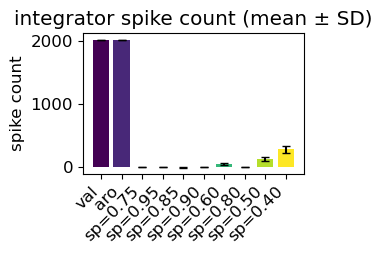

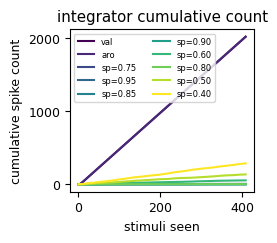

In [5]:
# plots

filename = f"simdata_magcode.npy"
dataVall = np.load(filename)

# one rater example, some time window
t_start = 7000
t_end   = 8000

dataVall_spk = dataVall.copy()
dataVall_spk[dataVall_spk >= thresh[:, :, None]] = 30 # for raster and voltage plots
dataV_ex = dataVall_spk[:, :, 0]
spk_neuron, spk_time = np.where(dataV_ex[:,t_start:t_end] >= thresh)   # thresh is (Nn,1), broadcasts

plt.figure(figsize=(4.5, 2.7))
plt.rcParams.update({'font.size': 9})
plt.plot(spk_time, spk_neuron, '.', markersize=2, color='k')
plt.xlabel('time (ms)')
plt.ylabel('neuron')
plt.title('spike raster')
plt.rcParams.update({'font.size': 12})        # set globally before plotting
plt.tight_layout()
plt.savefig('spike raster.svg', format='svg', bbox_inches='tight')

# define colors
import matplotlib.cm as cm
colors = cm.viridis(np.linspace(0, 1, N_int))   # N_int distinct colors
labels = ['val', 'aro'] + ['sp=%.2f' % sparseness[i] for i in range(2, N_int)]

# average bar charts of spike count across integrator
spc_all = np.zeros((N_int, N_it))
for j in range(N_it):
    dataV        = dataVall[:,:,j]
    crossed      = (dataV[N_magA:Nn, 1:] >= thresh[N_magA:Nn]) & (dataV[N_magA:Nn, :-1] < thresh[N_magA:Nn])
    spike_count  = crossed.sum(axis=1)
    spc_all[:,j] = spike_count
    
plt.figure(figsize=(3.3, 2.7))
means = spc_all.mean(axis=1)
stds  = spc_all.std(axis=1)
plt.bar(np.arange(N_int), means, yerr=stds, capsize=3, color=colors)
plt.xticks(np.arange(N_int), labels, rotation=45, ha='right')
plt.ylabel('spike count')
plt.title('integrator spike count (mean ± SD)')
plt.tight_layout()
plt.savefig('integrator_bars.svg', format='svg', bbox_inches='tight')

# average cumulative rising spike count across integrators
# same as above figure 2, but as line plot over time, averaged over runs
stim_edges = np.arange(0, t_sim+1, t_S)   # stimulus boundaries in ms
cumulative_all = np.zeros((N_int, N_pts, N_it))
for j in range(N_it):
    dV = dataVall[N_magA:Nn, :, j]
    crossed = (dV[:, 1:] >= thresh[N_magA:Nn]) & (dV[:, :-1] < thresh[N_magA:Nn])
    # spikes per stimulus window:
    per_stim = np.array([crossed[:, s*t_S:(s+1)*t_S].sum(axis=1) for s in range(N_pts)]).T  # (N_int, N_pts)
    cumulative_all[:, :, j] = np.cumsum(per_stim, axis=1)

cumulative_mean = cumulative_all.mean(axis=2)   # (N_int, N_pts)

plt.figure(figsize=(2.8, 2.6))
plt.rcParams.update({'font.size': 9})
for i in range(N_int):
    plt.plot(np.arange(1, N_pts+1), cumulative_mean[i], color=colors[i], label=labels[i])
plt.xlabel('stimuli seen'); plt.ylabel('cumulative spike count')
plt.title('integrator cumulative count')
plt.legend(fontsize=6, ncol=2)
plt.rcParams.update({'font.size': 12})        # set globally before plotting
plt.tight_layout()
plt.savefig('integrator_counts.svg', format='svg', bbox_inches='tight')


In [6]:
# FI curve

Nn     = 10
t      = 1
t_S    = 2000
t_sim  = t_S
dt     = 1  
dtvec  = np.ones((Nn,1), float)*dt
count  = -1
thresh = np.zeros((Nn,1), float)-40
refrac = 3/dt   

Tmem           = np.zeros((Nn,1), float)
Tmem[0:Nn,0]   = 4.17                                        
R              = np.zeros((Nn,1), float)
R[0:Nn,0]      = 15                                 

V_rest  = np.zeros((Nn,1), float)-70;                                       
E_leak  = V_rest.copy()
V_reset = np.zeros((Nn,1), float)-80;   

g_leak = 1 # left over, interpret as gain, not a leak conductance

Iext = np.zeros((Nn,1), float)
Vold = np.zeros((Nn,1), float) + V_rest  
Vnew = np.zeros((Nn,1), float)
Vbef = np.copy(Vold)

FRwindow = 100                                    # FR estimated from last 100 ms
buffer   = np.ones((Nn,FRwindow+1), float)*-1     # combined buffer for delayed synaptic transm. and FR estimate
buffind  = 0                                      # used to be 1 in matlab

clampflag    = np.zeros((Nn,1), float)
clampbef     = np.zeros((Nn,1), float)
intercept_dt = np.zeros((Nn,1), float)

frate  = np.zeros((Nn,1), float)   # dummy
dataV  = np.zeros((Nn,t_sim), float)-70
dataFR = np.zeros((Nn,t_sim), float)   

# adaptation
adap  = np.zeros((Nn,1), float)
b_adap = np.zeros((Nn,1), float)   # per-neuron strength; 0 for integrators for now
b_adap[:] = 0.2                    # free parameter
Tadap = 500                        # slow decay (ms)


### simulation loop

S_count = 0   # stimulus ID

#I_stim  = 2.3+0.1*np.arange(Nn).reshape(Nn, 1) # for testing
I_stim = np.array([2.3, 2.375, 2.49, 2.63, 2.79, 2.99, 3.25, 3.53, 3.9, 4.30]).reshape(Nn, 1) 
# range chosen for approximately equal rate steps

while t < t_sim:
    
    count = count + 1
    
    if t > 5:
        Iext = I_stim.copy()
    
    Vnew = Vold.copy()
    assert Vold is not Vnew and Vold is not Vbef and Vnew is not Vbef, \
    "state arrays aliased — copy-on-assign bug"
        
    ind1 = Vold>=thresh
    ind2 = Vbef<thresh
    ind3 = np.logical_and(ind1,ind2)   # determine which neurons crossed threshold
    
    if any(ind3):                                                          # does not affect clamped neurons       
        Vslopes              = np.copy(dtvec)                              # dtvec = prealloc ones*dt, length Nn
        Vslopes[ind3]        = (Vnew[ind3]-Vbef[ind3])/dt                  # cells that crossed thresh determine slope of V within timestep
        intercept_dt[ind3]   = (thresh[ind3]-Vbef[ind3])/Vslopes[ind3]     # dt - this = amount of dt-like integration within this timestep
        
        indW = np.where(ind3==True)
        
        buffer[indW[0],[buffind]] = t-dt+intercept_dt[ind3]                 # enter spike time in buffer
        
        buffer[:,buffind]    = buffer[:,buffind]*ind3[:,0]
        Vnew[ind3]         = V_reset[ind3]
        clampflag[ind3]    = refrac
        adap[ind3] += b_adap[ind3]         # additive jump per spike
        
    dtintneu = np.copy(dtvec)   # this needs to be aadapted when neuron exits refrec                                                                    
    ind4     = Vold<thresh      # see implementation note *5
    ind5     = clampflag<0                                                    
    ind7     = clampbef>=0

    if any(ind5):
        ind6   = np.logical_and(ind4,ind5)
    else:
        ind6   = np.zeros((Nn,1), bool)       

    dtint = np.copy(dtvec)                                   # integration dt same for all
    inddt = np.logical_and(ind6,ind7)                        # clamping released during this timestep
    if any(inddt):
        dtintneu[inddt] = dtint[inddt]-intercept_dt[inddt]   # see above notes *1 and *2             
        
        
    if any(ind6):                                                                             
        Vnew[ind6] = Vold[ind6] + dtintneu[ind6]/Tmem[ind6] * ( - g_leak*( Vold[ind6] - E_leak[ind6] )
        - adap[ind6] + R[ind6] * Iext[ind6] )
    
    adap  = adap + dt/Tadap*(-adap)
    
    dataV[:,[count]]          = Vold;
    
    Vbef      = Vold.copy() 
    Vold      = Vnew  # alias, broken next iteration by Vnew = Vold.copy()
    t         = t + dt
    clampbef  = clampflag.copy()
    clampflag = clampflag-1          #-1 because clampflag=refrac and refrac already devided by dt
    
print('Done')

filename1 = f"simdata_FIcurve.npy"
np.save(filename1, dataV)


Done


Text(0.5, 1.0, 'delta in FI curve')

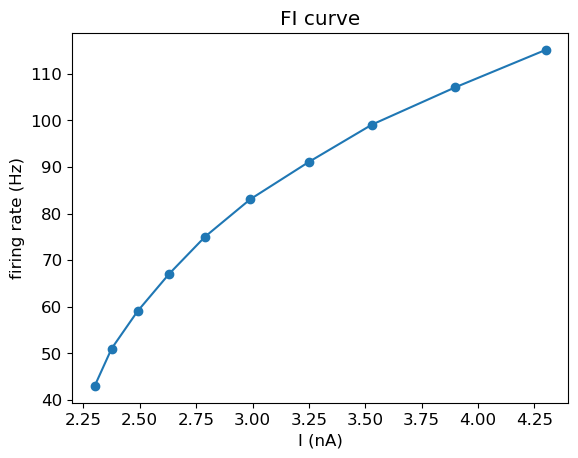

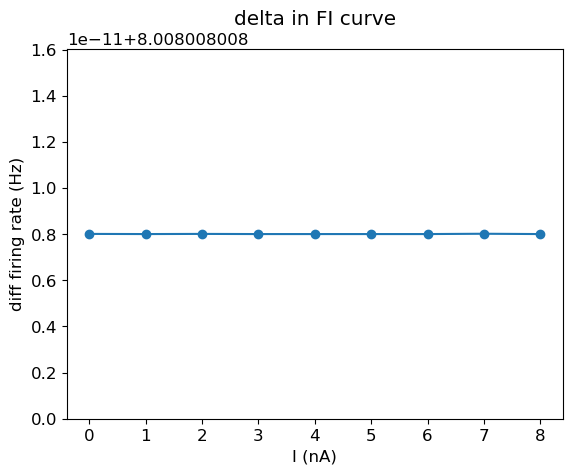

In [7]:
# Figure of FI curve

filename = f"simdata_FIcurve.npy"
dataV = np.load(filename)

spk_neuron, spk_time = np.where(dataV[:,1000:2000] >= thresh)   # thresh is (Nn,1), broadcasts

seg = dataV[:, 1000:2000]
crossed = (seg[:, 1:] >= thresh) & (seg[:, :-1] < thresh)
firing_rate = crossed.sum(axis=1) * 1000.0 / (seg.shape[1]-1)   # Hz

plt.figure(1)
plt.plot(I_stim, firing_rate, 'o-')   # current on x, rate on y
plt.xlabel('I (nA)'); plt.ylabel('firing rate (Hz)')
plt.title('FI curve')

plt.figure(2)
plt.plot(np.diff(firing_rate), 'o-')   # current on x, rate on y
plt.xlabel('I (nA)'); plt.ylabel('diff firing rate (Hz)')
plt.title('delta in FI curve')


In [8]:
# rate code detector

# regenerate attributes because of shuffle above
N_att = 10   # 2 of these are val aro
attributes = np.zeros([N_pts, N_att])
attributes[:,0] = val
attributes[:,1] = aro
attributes[:,2] = make_attribute(0.75,N_pts)
attributes[:,3] = make_attribute(0.95,N_pts)
attributes[:,4] = make_attribute(0.85,N_pts)
attributes[:,5] = make_attribute(0.90,N_pts)
attributes[:,6] = make_attribute(0.60,N_pts)
attributes[:,7] = make_attribute(0.80,N_pts)
attributes[:,8] = make_attribute(0.50,N_pts)
attributes[:,9] = make_attribute(0.40,N_pts)


### init
N_mag  = 1   # number of cells per magnitude bank
N_magA = 10 * N_mag
N_int  = 10   # number of integrator neurons
Nn     = N_magA + N_int
t      = 1
t_S    = 1000
t_sim  = N_pts*t_S # here longer for late adaptation effects
dt     = 1  
dtvec  = np.ones((Nn,1), float)*dt
count  = -1

thresh = np.zeros((Nn,1), float)-40
refrac = 3/dt   

Tmem              = np.zeros((Nn,1), float)
Tmem[0:N_magA,0]  = 4.17                                        
Tmem[N_magA:Nn,0] = 4.17  

R              = np.zeros((Nn,1), float)
R[0:N_magA,0]  = 15               
R[N_magA:Nn,0] = 15 

V_rest  = np.zeros((Nn,1), float)-70;                                       
E_leak  = V_rest.copy()
V_reset = np.zeros((Nn,1), float)-80;   

Iext = np.zeros((Nn,1), float)
Vold = np.zeros((Nn,1), float) + V_rest  
Vnew = np.zeros((Nn,1), float)
Vbef = np.copy(Vold)

g_leak = 1 # left over, interpret as gain, not a leak conductance

FRwindow = 100                                     # FR estimated from last 100 ms
buffer   = np.ones((Nn,FRwindow+1), float)*-1      # combined buffer for delayed synaptic transm. and FR estimate
buffind  = 0                                       

clampflag    = np.zeros((Nn,1), float)
clampbef     = np.zeros((Nn,1), float)
intercept_dt = np.zeros((Nn,1), float)

frate  = np.zeros((Nn,1), float)   # dummy
dataV  = np.zeros((Nn,t_sim), float)-70
dataFR = np.zeros((Nn,t_sim), float)   

delay  = 2   # synaptic delay

gAMPA = np.zeros((Nn,1), float);   dAMPA = 0.067;   Erev_ampa =   0;   Tampa    = 10
gNMDA = np.zeros((Nn,1), float);   dNMDA = 0.1;   Erev_nmda =   0;   Tnmda    = 100

AMPAincr = np.zeros((Nn,1), float);        
NMDAincr = np.zeros((Nn,1), float);

#cadaptation
adap  = np.zeros((Nn,1), float)
b_adap = np.zeros((Nn,1), float)     # per-neuron strength; 0 for integrators for now
b_adap[0:N_magA,0] = 0.2 #0          # free parameter
Tadap = 500                          # slow decay (ms)


### connectivity
Wampa   = np.zeros((Nn, Nn), float)
Wnmda   = np.zeros((Nn, Nn), float)
for i in range(N_magA):
    Wampa[N_magA+i, i] = 1   # [target_row, source_cols]
    Wnmda[N_magA+i, i] = 1


### simulation loop

S_count = 0   # stimulus ID

I_stim = np.array([0, 2.3, 2.375, 2.49, 2.63, 2.79, 2.99, 3.25, 3.53, 3.9, 4.30]) 
# for approximately equal rate steps, see FI curve above

while t < t_sim:
    
    count = count + 1
    
    if (t-1) % t_S == 0 and S_count < N_pts:
        rate_ind = assign_rates(attributes[S_count,:], N_magA)
        Iext[0:N_magA,0] = I_stim[rate_ind] 
        S_count += 1
        
    Vnew = Vold.copy()
    assert Vold is not Vnew and Vold is not Vbef and Vnew is not Vbef, \
    "state arrays aliased — copy-on-assign bug"
        
    ind1 = Vold>=thresh
    ind2 = Vbef<thresh
    ind3 = np.logical_and(ind1,ind2)   # determine which neurons crossed threshold
    
    if any(ind3):                                                          # does not affect clamped neurons       
        Vslopes              = np.copy(dtvec)                              # dtvec = prealloc ones*dt, length Nn
        Vslopes[ind3]        = (Vnew[ind3]-Vbef[ind3])/dt                  # cells that crossed thresh determine slope of V within timestep
        intercept_dt[ind3]   = (thresh[ind3]-Vbef[ind3])/Vslopes[ind3]     # dt - this = amount of dt-like integration within this timestep
        
        indW = np.where(ind3==True)
        
        buffer[indW[0],[buffind]] = t-dt+intercept_dt[ind3]                 # enter spike time in buffer
        
        buffer[:,buffind]    = buffer[:,buffind]*ind3[:,0]
        Vnew[ind3]         = V_reset[ind3]
        clampflag[ind3]    = refrac
        adap[ind3] += b_adap[ind3]         # additive jump per spike
        
    dtintneu = np.copy(dtvec)   # this needs to be aadapted when neuron exits refrec                                                                    
    ind4     = Vold<thresh      # see implementation note *5
    ind5     = clampflag<0                                                    
    ind7     = clampbef>=0

    if any(ind5):
        ind6   = np.logical_and(ind4,ind5)
    else:
        ind6   = np.zeros((Nn,1), bool)       

    dtint = np.copy(dtvec)                                   # integration dt same for all
    inddt = np.logical_and(ind6,ind7)                        # clamping released during this timestep
    if any(inddt):
        dtintneu[inddt] = dtint[inddt]-intercept_dt[inddt]   # see above notes *1 and *2             

    if t > delay + 1:
        b_ind = int(buffind - delay)
        if b_ind < 0:
            b_ind += FRwindow + 1         

        indSP = buffer[:, b_ind] > 0

        scaledAMPA = np.inner(Wampa, indSP).reshape(-1, 1)
        scaledNMDA = np.inner(Wnmda, indSP).reshape(-1, 1)

        gAMPA += dAMPA * scaledAMPA        # all cells, refractory or not
        gNMDA += dNMDA * scaledNMDA
        
    if any(ind6): 
        Vnew[ind6] = Vold[ind6] + dtintneu[ind6]/Tmem[ind6] * ( - g_leak*( Vold[ind6] - E_leak[ind6] )
        - adap[ind6] + R[ind6] * Iext[ind6] ) + dtint[ind6] / Tmem[ind6] * ( - gAMPA[ind6] * (Vold[ind6] - Erev_ampa) 
        - gNMDA[ind6] * (Vold[ind6] - Erev_nmda) )     

    gAMPA = gAMPA + dt/Tampa*(-gAMPA)
    gNMDA = gNMDA + dt/Tnmda*(-gNMDA)
    
    adap  = adap + dt/Tadap*(-adap)
    
    if t<101:
        FR = np.sum(buffer>0,1)*1000/FRwindow;   # slow, but can be substituted once buffer filled
    else:
        newest = (buffer[:,buffind] > 0).astype(float)
        FR = FRbef + (newest - oldest) * 1000 / FRwindow

    dataV[:,[count]]          = Vold;
    dataFR[:,[count]]         = np.transpose([FR]);
    
    Vbef      = Vold.copy() 
    Vold      = Vnew  # alias, broken next iteration by Vnew = Vold.copy()
    t         = t + dt
    FRbef     = FR
    clampbef  = clampflag.copy()
    clampflag = clampflag-1          #-1 because clampflag=refrac and refrac already devided by dt
        
    buffind = (buffind + 1) % 101

    oldest = (buffer[:,buffind] > 0).astype(float)
    buffer[:,buffind] = 0            # buffind updated, zero out what was previously written there, 100 ms ago
    
    AMPAincr[:] = 0
    NMDAincr[:] = 0
    
print('Done')

filename1 = f"simdata_RateCode_magcode.npy"
#filename1 = f"RateCode_magcode_adapOFF.npy"
np.save(filename1, dataV)


Done


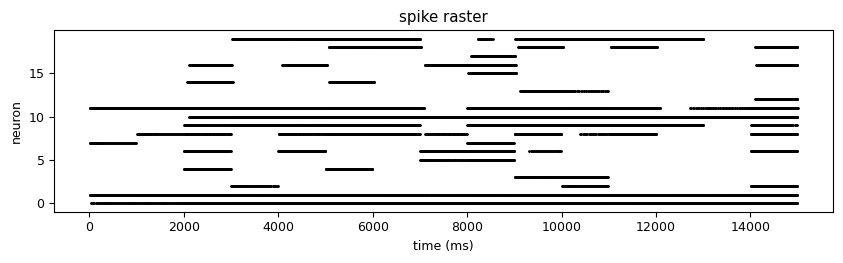

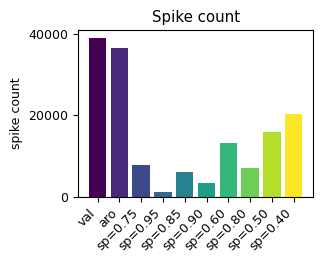

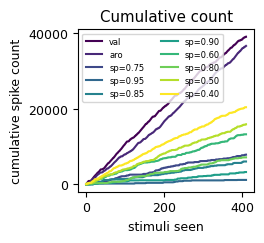

In [9]:
# plots for rate code

filename = f"simdata_RateCode_magcode.npy"
dataV = np.load(filename)

tend = t_sim

spk_neuron, spk_time = np.where(dataV[:,0:tend] >= thresh)   # thresh is (Nn,1), broadcasts

crossed = (dataV[N_magA:Nn, 1:] >= thresh[N_magA:Nn]) & (dataV[N_magA:Nn, :-1] < thresh[N_magA:Nn])
spike_count = crossed.sum(axis=1)

# one rater example, some time window
t_start = 10000
t_end   = 25000

spk_neuron, spk_time = np.where(dataV[:,t_start:t_end] >= thresh)   # thresh is (Nn,1), broadcasts

plt.figure(figsize=(8.5, 2.7))
plt.rcParams.update({'font.size': 9})
plt.plot(spk_time, spk_neuron, '.', markersize=2, color='k')
plt.xlabel('time (ms)')
plt.ylabel('neuron')
plt.title('spike raster')
plt.tight_layout()
plt.savefig('ratecode_spike_raster.svg', format='svg', bbox_inches='tight')


# define colors once
import matplotlib.cm as cm
colors = cm.viridis(np.linspace(0, 1, N_int))   # N_int distinct colors
labels = ['val', 'aro'] + ['sp=%.2f' % sparseness[i] for i in range(2, N_int)]

# average bar charts of spike count across integrator
spc_all = np.zeros((N_int))
crossed = (dataV[N_magA:Nn, 1:] >= thresh[N_magA:Nn]) & (dataV[N_magA:Nn, :-1] < thresh[N_magA:Nn])
spike_count = crossed.sum(axis=1)
    
plt.figure(figsize=(3.3, 2.7))
plt.bar(np.arange(N_int), spike_count, capsize=3, color=colors)
plt.xticks(np.arange(N_int), labels, rotation=45, ha='right')
plt.ylabel('spike count')
plt.title('Spike count')
plt.tight_layout()
plt.savefig('ratecode_integrator_bars.svg', format='svg', bbox_inches='tight')


# average cumulative rising spike count across integrators
# same as above figure above, but as line plot over time
stim_edges = np.arange(0, t_sim+1, t_S)   # stimulus boundaries in ms
dV = dataV[N_magA:Nn, :]
crossed = (dV[:, 1:] >= thresh[N_magA:Nn]) & (dV[:, :-1] < thresh[N_magA:Nn])
# spikes per stimulus window:
per_stim = np.array([crossed[:, s*t_S:(s+1)*t_S].sum(axis=1) for s in range(N_pts)]).T  # (N_int, N_pts)
cumulative = np.cumsum(per_stim, axis=1)   # (N_int, N_pts), rising

plt.figure(figsize=(2.8, 2.6))
plt.rcParams.update({'font.size': 9})
for i in range(N_int):
    plt.plot(np.arange(1, N_pts+1), cumulative[i], color=colors[i], label=labels[i])
plt.xlabel('stimuli seen'); plt.ylabel('cumulative spike count')
plt.title('Cumulative count')
plt.legend(fontsize=6, ncol=2)
plt.rcParams.update({'font.size': 12})        # set globally before plotting
plt.tight_layout()
plt.savefig('ratecode_integrator_counts.svg', format='svg', bbox_inches='tight')


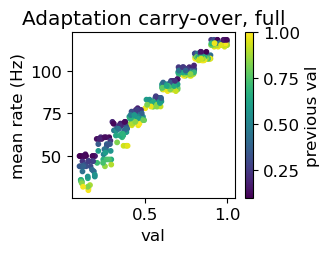

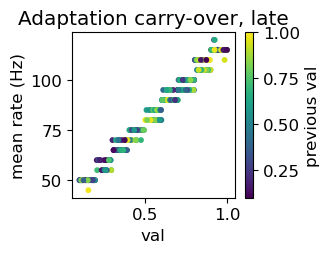

In [10]:
# adaptation carry over

filename = f"simdata_RateCode_magcode.npy"
dataV    = np.load(filename)

b      = 0   # valence bank
sfull  = dataV[0:N_magA, :]                      # all banks, full time
crfull = (sfull[:, 1:] >= thresh[0:N_magA]) & (sfull[:, :-1] < thresh[0:N_magA])
n_stim = crfull.shape[1] // t_S                   # whole windows only
usable = n_stim * t_S
window = crfull[:, :usable].reshape(N_magA, n_stim, t_S)
early  = 500
tail   = 200

per_stim_rate  = window.sum(axis=2)            * 1000.0 / t_S
per_stim_early = window[:, :, :early].sum(2)   * 1000.0 / early
per_stim_late  = window[:, :, -tail:].sum(2)   * 1000.0 / tail

prev_val = np.concatenate([[np.nan], val[:n_stim-1]])   # compute once

plt.figure(figsize=(3.3, 2.7))
sc = plt.scatter(val[:n_stim], per_stim_rate[b], c=prev_val, cmap='viridis',s=10)
plt.colorbar(sc, label='previous val')
plt.xlabel('val'); plt.ylabel('mean rate (Hz)')
plt.title('Adaptation carry-over, full')
plt.tight_layout()
plt.savefig('Adaptation_carryover_full.svg', format='svg', bbox_inches='tight')

plt.figure(figsize=(3.3, 2.7))
sc = plt.scatter(val[:n_stim], per_stim_late[b], c=prev_val, cmap='viridis',s=10)
plt.colorbar(sc, label='previous val')
plt.xlabel('val'); plt.ylabel('mean rate (Hz)')
plt.title('Adaptation carry-over, late')
plt.tight_layout()
plt.savefig('Adaptation_carryover_late.svg', format='svg', bbox_inches='tight')
